# 04_概率分布-多项分布

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


咱们来聊聊多项分布\~

简单来说，多项分布是一种描述多次实验中不同事件出现频率的概率分布。

在概率论和统计学中，当我们有多个可能的结果，每个结果在每次试验中发生的概率是已知的，且每次试验之间是独立的时，**多项分布**就可以用来描述这种情形。

举个简单的例子：

假设你正在进行一个投掷色子实验。色子有6个面，每个面分别显示出1至6的数字，投掷色子时，每一面的出现概率是相等的（即1/6）。假设你投掷了色子10次，你想要知道每个数字分别出现多少次，那么可以使用**多项分布**来描述这个问题。

在这个实验中，有6个不同的结果（1, 2, 3, 4, 5, 6），而每次投掷的结果是独立的。多项分布就是用来描述这样的多次独立实验中每个结果发生次数的概率。

### 多项分布的本质

多项分布是**二项分布**的推广。**二项分布**描述的是只有两种可能结果的情况（比如投掷硬币），而多项分布则适用于有三个或更多可能结果的情况。

如果我们有一个实验，这个实验可以有多个不同的结果，并且每个结果都有一定的概率，那么多项分布就可以用来计算不同结果出现的次数的概率。简单来说，多项分布不仅告诉你某个结果出现的概率，还可以给出多个不同结果同时出现的概率。

### 多项分布的特点

- **多个结果**：多项分布处理的是具有多个可能结果的情况。
- **独立实验**：每个试验的结果是独立的，这意味着一个实验的结果不会影响另一个实验的结果。
- **固定次数**：多项分布要求试验次数是固定的。
- **每个结果的概率**：每个不同的结果在每次试验中都有一个固定的概率，这些概率之和为1。
- **计数类型**：多项分布通常用于描述事件出现的次数。

我们来考虑一个包含三个可能结果的随机实验：抽取一个球，球的颜色可能是红色（R）、蓝色（B）或绿色（G）。我们设定每种颜色的球被选中的概率分别为：

- 红球（R）：概率为 0.5
- 蓝球（B）：概率为 0.3
- 绿球（G）：概率为 0.2

现在我们重复这个实验共 **10 次**，每次实验相互独立，且抽取球的概率保持不变。我们关心的问题是：在这 10 次实验中，红、蓝、绿三种颜色分别出现的次数是多少？比如，我们可能得到这样的一个结果：红球出现了 5 次，蓝球 3 次，绿球 2 次。

由于这个实验有多个可能结果，并且我们关注的是每种结果在固定次数实验中出现的频数分布，这正是 **多项分布（Multinomial Distribution）** 的应用场景。

用数学语言来说，如果我们记：

$X_R$：红球出现的次数

$X_B$：蓝球出现的次数

$X_G$：绿球出现的次数

那么我们可以表示这组变量服从一个多项分布：


$$
(X_R, X_B, X_G) \sim \text{Multinomial}(n = 10, p = [0.5, 0.3, 0.2])
$$


其中 $n = 10$是实验总次数，$p = [0.5, 0.3, 0.2]$是每种结果的概率分布。

我们可以用这个分布来计算特定结果出现的概率，比如：


$$
P(X_R = 5, X_B = 3, X_G = 2)
$$


这个概率可以用多项分布的概率质量函数（PMF）来计算：


$$
P(X_R = 5, X_B = 3, X_G = 2) = \frac{10!}{5! \cdot 3! \cdot 2!} \cdot 0.5^5 \cdot 0.3^3 \cdot 0.2^2
$$


这个表达式告诉我们，在进行10次实验的前提下，红球出现5次、蓝球3次、绿球2次的具体概率是多少。

## 公式推导

### 1. 多项分布的定义

如果我们进行 $n$ 次实验，每次实验有 $k$ 个可能的结果，分别为 $X_1, X_2, \dots, X_k$，其中第 $i$ 个结果出现的概率为 $p_i$，且所有的 $p_i$ 满足：  
$p_1 + p_2 + \dots + p_k = 1$  
那么多项分布描述的是这 $n$ 次实验中，各个结果出现次数的概率分布。

### 2. 结果出现次数的表示

我们用一个向量 $\mathbf{X} = (X_1, X_2, \dots, X_k)$来表示每个结果 $X_1, X_2, \dots, X_k$ 在 $n$ 次实验中分别出现的次数，满足：  
$X_1 + X_2 + \dots + X_k = n$  
其中 $X_i$ 是第 $i$ 种结果出现的次数，且 $X_i \geq 0$ 是整数。

### 3. 多项分布的概率质量函数（PMF）

多项分布的概率质量函数（PMF）给出的是在 $n$ 次实验中，第 $i$ 种结果出现 $X_i$ 次的概率。它的公式为：  
$P(X_1 = x_1, X_2 = x_2, \dots, X_k = x_k) = \binom{n}{x_1, x_2, \dots, x_k} p_1^{x_1} p_2^{x_2} \dots p_k^{x_k}$  
其中：

$\binom{n}{x_1, x_2, \dots, x_k}$ 是多项式系数，表示从 $n$ 次实验中选出 $x_1$ 次 $X_1$、$x_2$ 次 $X_2$、...、$x_k$ 次 $X_k$ 的方式数，公式为：  
$\binom{n}{x_1, x_2, \dots, x_k} = \frac{n!}{x_1! x_2! \dots x_k!}$

$p_1^{x_1} p_2^{x_2} \dots p_k^{x_k}$ 是每种结果出现 $x_i$ 次的概率。

### 4. 公式推导过程

1. **从二项分布推广**：二项分布是多项分布的特例。当 $k = 2$ 时，多项分布退化为二项分布。
2. **组合计数**：多项式系数 $\binom{n}{x_1, x_2, \dots, x_k}$ 计算了在 $n$ 次实验中，如何分配每个结果出现的次数。

因此，多项分布的公式实质上是通过组合计数来找到不同结果发生的方式，再乘上每种结果发生的概率的幂。

## 代码实现

### 1. 使用Python生成多项分布的数据

首先，我们来实现一个简单的例子，模拟多项分布并进行可视化。

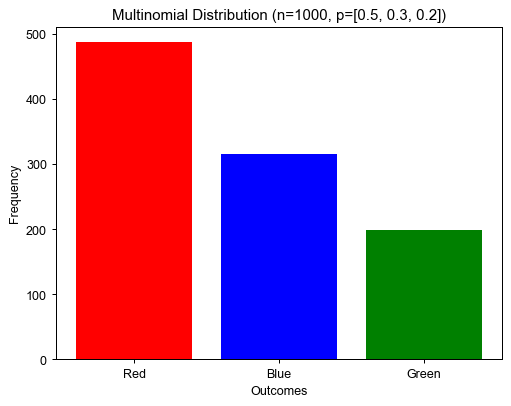

实验中红球出现次数：487
实验中蓝球出现次数：315
实验中绿球出现次数：198


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 设置参数
n = 1000  # 实验次数
p = [0.5, 0.3, 0.2]  # 红球、蓝球、绿球的概率
k = len(p)  # 结果种类数

# 使用numpy的multinomial函数生成数据
data = np.random.multinomial(n, p, size=1)[0]

# 可视化结果
labels = ['Red', 'Blue', 'Green']
plt.bar(labels, data, color=['red', 'blue', 'green'])
plt.title(f'Multinomial Distribution (n={n}, p={p})')
plt.xlabel('Outcomes')
plt.ylabel('Frequency')
plt.show()

# 输出实验结果
print(f'实验中红球出现次数：{data[0]}')
print(f'实验中蓝球出现次数：{data[1]}')
print(f'实验中绿球出现次数：{data[2]}')

#实验中红球出现次数：490
#实验中蓝球出现次数：313
#实验中绿球出现次数：197

![原文参考图，当前结果见代码输出](attachments/img_002.png)

运行上述代码，你将得到一个条形图，展示红球、蓝球和绿球在1000次实验中各自的出现频率。

### 最后

多项分布描述了多个结果在固定次数实验中的出现频率，适用于结果种类超过两个的情况。通过组合数和各结果概率的幂，得到多项分布的概率质量函数。